# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model as m       # I've put all the functions in a separate Python file


(ipykernel_launcher.py:148974): dbind-WARNING **: 17:36:46.573: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [2]:
# parameters of the simulation
par={'N': 10,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.5,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 2,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0+1*x,              # initial transfer function shape (here linear)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'n_iter': 100,
     'N_sol': 20}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean = m.evolution(par,verb=3,gen_verb=False)

Iteration #0...
Mean loss: 3.7661702538702185e+202
Parents indexes: [[1 5]
 [0 6]
 [2 3]
 [1 6]
 [2 0]
 [0 2]
 [3 1]
 [4 0]]
Selection Probabilities: [5.43281886e-01 1.09860368e-01 1.03058873e-01 5.79665596e-02
 5.11737730e-02 4.49741839e-02 2.80377120e-02 2.66046092e-02
 2.02385558e-02 8.32170407e-03 3.95578036e-03 2.25851324e-03
 1.24302115e-04 6.72356138e-05 5.83962693e-05 1.24620515e-05
 2.75283899e-06 1.68003049e-06 6.51850223e-07 5.81962767e-10]
Inverse losses: [3.59479202e-03 7.26924983e-04 6.81920794e-04 3.83553605e-04
 3.38607039e-04 2.97585547e-04 1.85520161e-04 1.76037595e-04
 1.33914641e-04 5.50631194e-05 2.61746398e-05 1.49441488e-05
 8.22483247e-07 4.44885158e-07 3.86396912e-07 8.24590044e-08
 1.82150075e-08 1.11164394e-08 4.31316788e-09 3.85073599e-12]


/home/pietromalagoli/ne/main/model.py:272: RuntimeWarning: overflow encountered in scalar power
  loss_inv = np.array([1/(sol.loss**2) for sol in solutions])


Iteration #1...
Mean loss: 26.58920650882461
Parents indexes: [[1 0]
 [0 1]
 [2 3]
 [2 1]
 [0 2]
 [1 0]
 [1 0]
 [0 3]]
Selection Probabilities: [4.49037827e-01 2.30687979e-01 2.12427698e-01 6.87148087e-02
 1.06095982e-02 5.60399823e-03 5.14020180e-03 5.12791766e-03
 3.27152511e-03 3.19365765e-03 3.14414500e-03 1.62160044e-03
 8.64493180e-04 4.26156043e-04 1.28393183e-04 1.98181700e-22
 3.49676360e-32 1.38324064e-37 3.37282108e-46 0.00000000e+00]
Inverse losses: [1.32901390e-01 6.82765487e-02 6.28720671e-02 2.03374706e-02
 3.14011485e-03 1.65861117e-03 1.52134168e-03 1.51770596e-03
 9.68270840e-04 9.45224466e-04 9.30570246e-04 4.79943869e-04
 2.55863400e-04 1.26129086e-04 3.80004345e-05 5.86556897e-23
 1.03493451e-32 4.09396700e-38 9.98251333e-47 0.00000000e+00]
Iteration #2...
Mean loss: 999.5559779458779
Parents indexes: [[0 1]
 [1 0]
 [0 4]
 [0 3]
 [0 1]
 [0 2]
 [0 4]
 [0 3]]
Selection Probabilities: [8.12387084e-01 7.41471268e-02 3.20817938e-02 2.60159906e-02
 2.40399902e-02 1.54826

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 16


In [15]:
s = copy.deepcopy(solutions)
for n,sol in enumerate(s[:20]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    print(f'loss:{loss}')

Solution #0
Input: [0, 0] -> Output: 0.9217483344301123
Target distance:0.7218541308480276
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: 0.9577052684273037
Target distance:3.1999639969260384e-06
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: 0.880773537002038
Target distance:0.0002020647886906477
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: 0.9868367060551422
Target distance:0.9483773647514703
Volume cost:1.7485144457345807e-06
loss:0.4626528581761288
Solution #1
Input: [0, 0] -> Output: -0.3151030301178102
Target distance:0.009858488132074603
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: 0.11949395491778289
Target distance:0.6010759725309565
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: -0.022336171260074256
Target distance:1.0923829356949772
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: 0.12398239582699275
Target distance:0.0002362871464330426
Volume cost:1.7485144457345807e-06
loss:0.4866183909511845

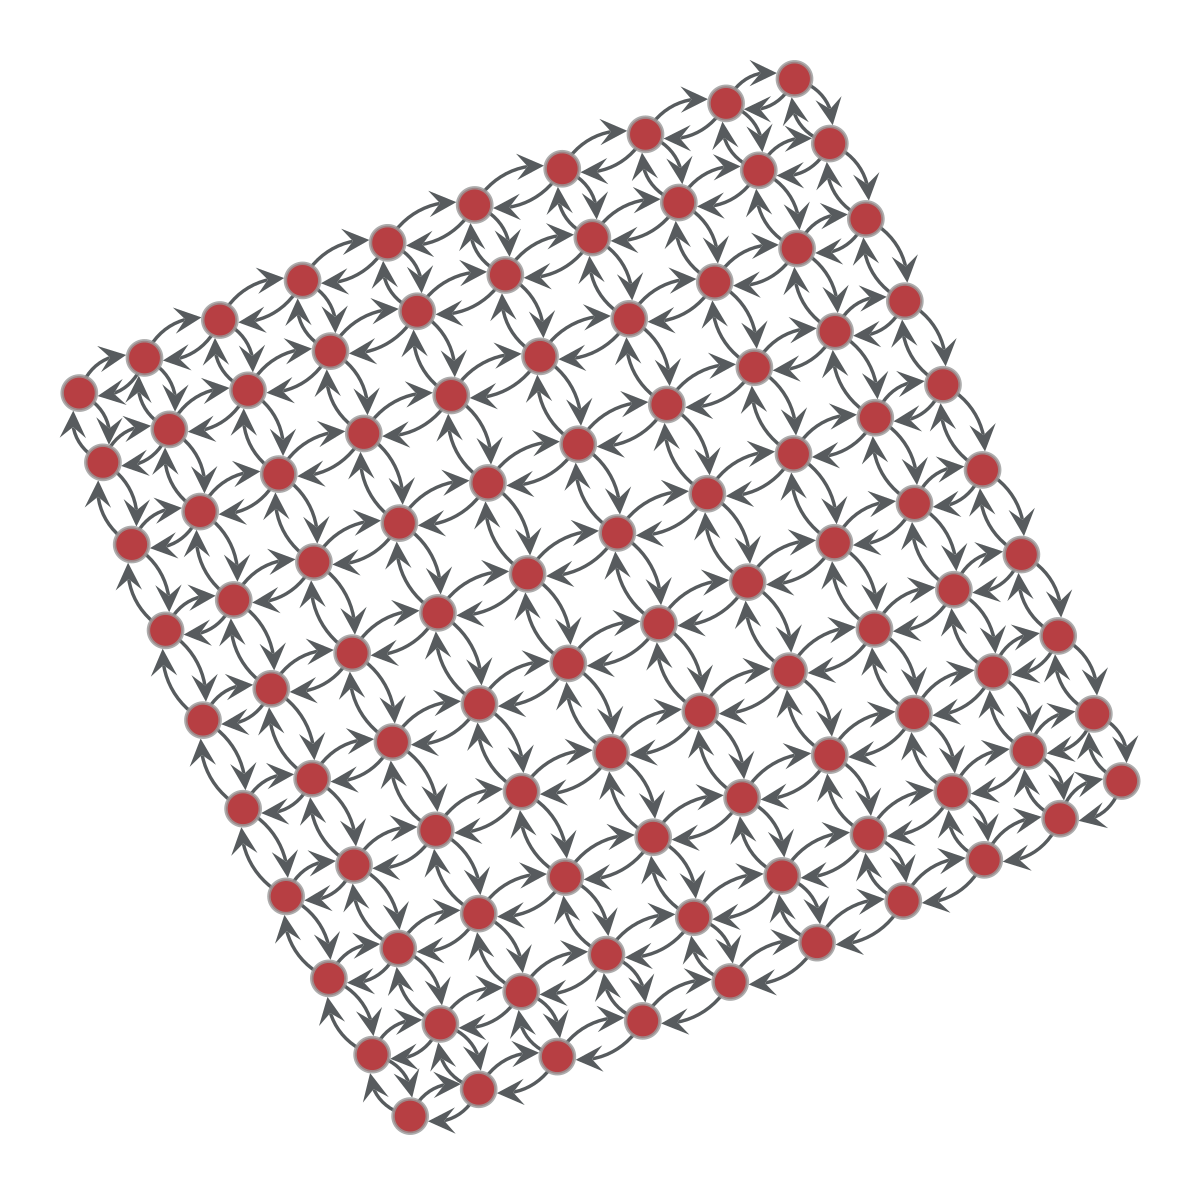

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x721b409b42c0, at 0x721b3ea0fce0>

In [6]:
graph_draw(s[0].G)

In [7]:
print(f'Percentage of links over the maximum possible:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Percentage of links over the maximum possible:0.036


In [8]:
np.array([sol.loss for sol in s])

array([3.17339468e-01, 5.80231556e-01, 8.03086604e-01, 8.80521322e-01,
       9.53649794e-02, 7.11552604e-01, 1.78231732e+04, 1.77144085e-01,
       7.10198799e+07, 4.80215309e-01, 2.07471242e+01, 5.55600634e-01,
       5.82008575e-01, 2.43930209e-01, 5.21725355e-01, 1.14401551e+01,
       4.44192215e-01, 4.84181728e-01, 5.83338474e-01, 4.30348565e+01])

In [9]:
for input in par['input_set']:
    output = m.ff(input,s[0],par)
    print(f'Input:{input} -> Output:{output}')

Input:[0, 0] -> Output:0.563901528381235
Input:[0, 1] -> Output:0.9370114663977096
Input:[1, 0] -> Output:0.9902275271720316
Input:[1, 1] -> Output:0.9239111292083568


In [10]:
mean_loss = np.mean(np.array([sol.loss for sol in s]))
print(mean_loss)

3551889.286417474


In [11]:
def plot_T(T:np.ndarray,par:dict) -> None:
    """Function to plot the shape of the transfer function given the Fourier coefficients.

    Args:
        T (np.ndarray): array of the Fourier coefficients of A SINGLE cell.
        par (dict): simulation parameters.
    """
    f_n = np.fft.irfft(T)
    coeff = np.polyfit(par['x_n'],f_n,3)    # fit the series of function value with a polynomial of degree up to 5
    new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
    x = np.linspace(min(par['x_n']),max(par['x_n']),1000)
    x = np.linspace(-10,10,1000)
    plt.plot(x,new_fun(x))
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Transfer function')
    plt.show()

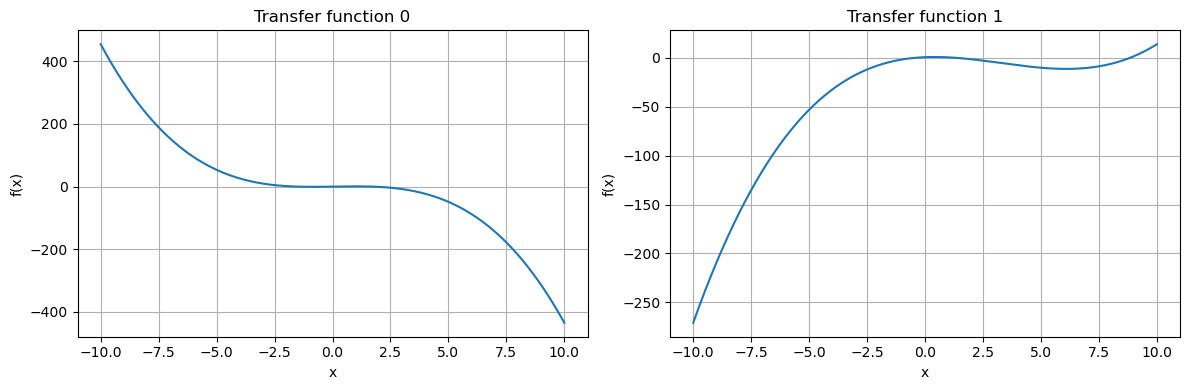

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    f_n = np.fft.irfft(solutions[0].T[i])
    coeff = np.polyfit(par['x_n'], f_n, 3)
    new_fun = np.poly1d(coeff)
    x = np.linspace(min(par['x_n']), max(par['x_n']), 1000)
    x = np.linspace(-10, 10, 1000)
    axes[i].plot(x, new_fun(x))
    axes[i].grid()
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].set_title(f'Transfer function {i}')
plt.tight_layout()
plt.show()

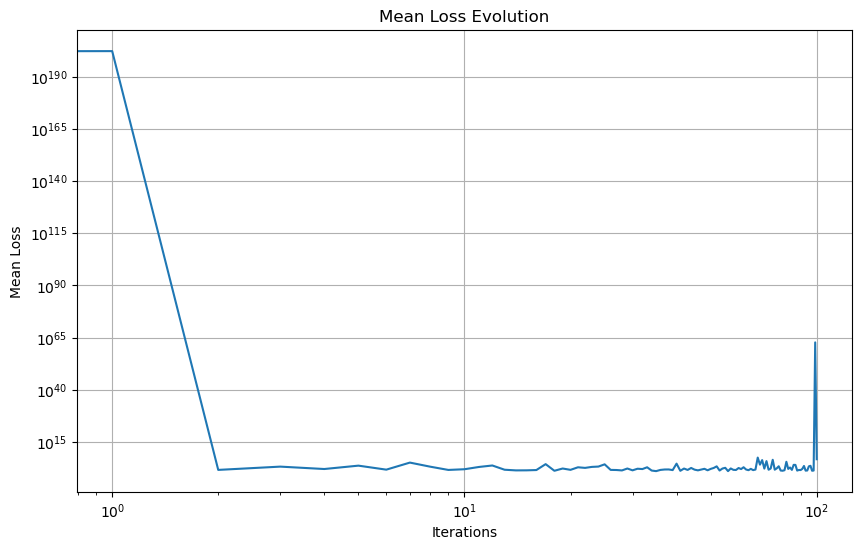

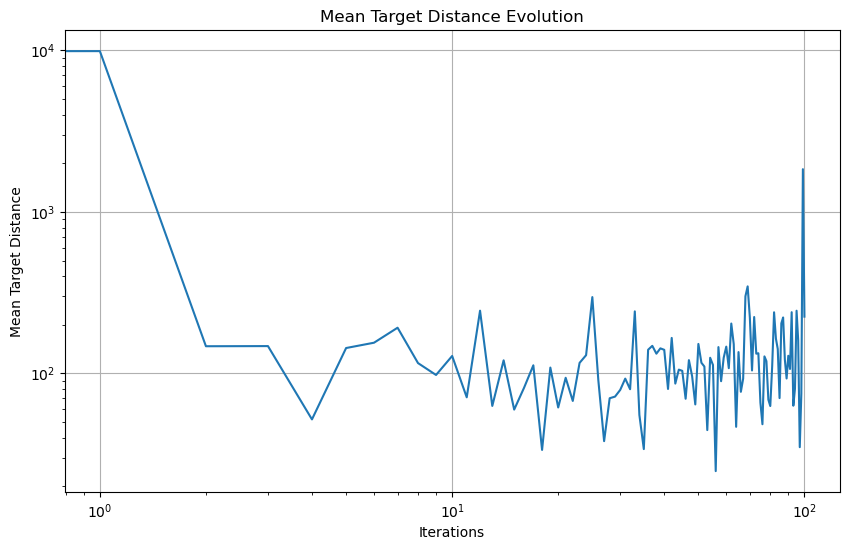

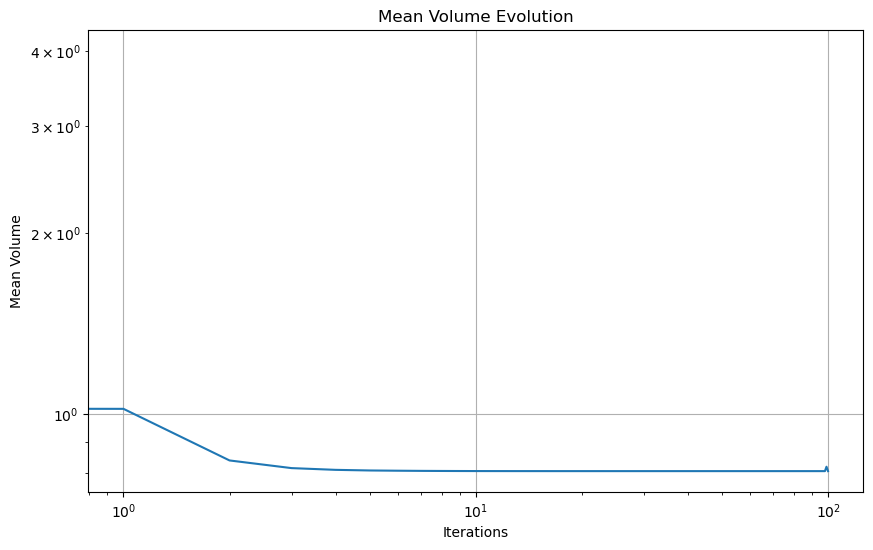

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(lmean)
plt.title('Mean Loss Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Loss')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()